# MJX Domain Randomization for V3 Cable

This notebook uses `testing/experiments/pipe_insert/V3/env.py` directly.
It visualizes the five reset/model randomization effects used for V3 cable experiments:

1. delta placement randomization
2. stiffness randomization
3. cable length randomization
4. reset precurvature
5. all randomizations combined



In [1]:
import math
import importlib.util
import types
import sys
from dataclasses import dataclass
from pathlib import Path

import jax
import jax.numpy as jp
import matplotlib.pyplot as plt
import mujoco as mj
import numpy as np
from mujoco import mjx
from mujoco_playground._src import mjx_env

def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "testing").exists() and (path / "skrl").exists():
            return path
    raise RuntimeError("Could not locate repository root containing 'testing' and 'skrl'")

repo_root = find_repo_root(Path.cwd())
if repo_root.as_posix() not in sys.path:
    sys.path.insert(0, repo_root.as_posix())
else:
    sys.path.remove(repo_root.as_posix())
    sys.path.insert(0, repo_root.as_posix())

# Force the repo-local `utils/` directory to be importable as `utils.*`.
# This avoids collisions with notebook/third-party modules named `utils`.
utils_dir = repo_root / "utils"
utils_pkg = types.ModuleType("utils")
utils_pkg.__path__ = [utils_dir.as_posix()]
utils_pkg.__package__ = "utils"
utils_pkg.__file__ = (utils_dir / "__init__.py").as_posix()
sys.modules["utils"] = utils_pkg

mjx_spec = importlib.util.spec_from_file_location("utils.mjx", utils_dir / "mjx.py")
utils_mjx = importlib.util.module_from_spec(mjx_spec)
sys.modules["utils.mjx"] = utils_mjx
mjx_spec.loader.exec_module(utils_mjx)

from testing.experiments.pipe_insert.V3.env import PipeInsert2, default_config

cfg = default_config()
cfg.impl = "jax"
cfg.episode_length = 300

env = PipeInsert2(config=cfg)
print(f"observation_size={env.observation_size}, action_size={env.action_size}, impl={env.impl}")


['cable:Jfirst', 'cable:J2', 'cable:J3', 'cable:J4', 'cable:J5', 'cable:J6', 'cable:J7', 'cable:J8', 'cable:Jlast']
observation_size=6, action_size=6, impl=jax


In [2]:
cable_stiffness_multiplier_range = (0.01, 10.0)


@dataclass
class CableVariant:
    index: int
    scale: float
    youngs: float
    shear: float
    joint_stiffness: float
    mjx_model: mjx.Model


def cable_randomization_spec(
    mj_model: mj.MjModel,
    multiplier_range: tuple[float, float] = cable_stiffness_multiplier_range,
) -> dict:
    cable_joint_ids = np.array(
        [
            j
            for j in range(mj_model.njnt)
            if mj_model.joint(j).name.startswith("cable:J")
        ],
        dtype=np.int32,
    )
    cable_geom_id = None
    for geom_name in ("cable:G1", "cable:G2", "cable:Gfirst", "cable:Glast"):
        try:
            cable_geom_id = mj_model.geom(geom_name).id
            break
        except KeyError:
            continue
    if cable_joint_ids.size and cable_geom_id is None:
        raise ValueError("Cable joints found but no cable geom to infer stiffness.")

    geom_size = np.asarray(mj_model.geom_size[cable_geom_id], dtype=np.float64)
    radius = float(geom_size[0])
    half_segment_length = float(geom_size[1])
    segment_length = 2 * half_segment_length

    cable_j = np.pi * radius**4 / 2.0
    cable_iy = np.pi * radius**4 / 4.0
    cable_iz = cable_iy

    # Match testing.experiments.pipe_insert.V3.env.domain_randomize.
    cable_youngs_base = 10000000.0 * 5
    cable_shear_base = 60000.0 * 1000

    cable_youngs_range = (
        float(multiplier_range[0]) * cable_youngs_base,
        float(multiplier_range[1]) * cable_youngs_base,
    )
    cable_shear_range = (
        float(multiplier_range[0]) * cable_shear_base,
        float(multiplier_range[1]) * cable_shear_base,
    )
    stiffness_range = (
        cable_joint_stiffness(
            cable_j,
            cable_iy,
            cable_iz,
            segment_length,
            cable_youngs_range[0],
            cable_shear_range[0],
        ),
        cable_joint_stiffness(
            cable_j,
            cable_iy,
            cable_iz,
            segment_length,
            cable_youngs_range[1],
            cable_shear_range[1],
        ),
    )

    return {
        "joint_ids": cable_joint_ids,
        "segment_length": max(segment_length, 1e-9),
        "cable_j": cable_j,
        "cable_iy": cable_iy,
        "cable_iz": cable_iz,
        "youngs_range": cable_youngs_range,
        "shear_range": cable_shear_range,
        "stiffness_range": stiffness_range,
    }



def cable_joint_stiffness(
    cable_j: float,
    cable_iy: float,
    cable_iz: float,
    segment_length: float,
    youngs: float,
    shear: float,
) -> float:
    length = max(segment_length, 1e-9)
    k_twist = (cable_j * shear) / length
    k_bend = ((cable_iy + cable_iz) * youngs) / length
    return float((k_twist + k_bend) / 3.0)


def evenly_sample_cable_variants(env: PipeInsert2, num_samples: int = 6):
    spec = cable_randomization_spec(env.mj_model)
    scales = np.linspace(0.0, 1.0, num_samples)
    variants = []

    for index, scale in enumerate(scales):
        youngs = float(np.exp(np.interp(scale, [0.0, 1.0], np.log(spec["youngs_range"]))))
        shear = float(np.exp(np.interp(scale, [0.0, 1.0], np.log(spec["shear_range"]))))

        k_ball = cable_joint_stiffness(
            spec["cable_j"],
            spec["cable_iy"],
            spec["cable_iz"],
            spec["segment_length"],
            youngs,
            shear,
        )
        cable_k = jp.full((spec["joint_ids"].shape[0],), k_ball)

        randomized_model = env.mjx_model.tree_replace(
            {
                "jnt_stiffness": env.mjx_model.jnt_stiffness.at[spec["joint_ids"]].set(cable_k)
            }
        )

        variants.append(
            CableVariant(
                index=index,
                scale=float(scale),
                youngs=float(youngs),
                shear=float(shear),
                joint_stiffness=float(k_ball),
                mjx_model=randomized_model,
            )
        )

    return variants


def rollout_with_model(
    env: PipeInsert2,
    randomized_model: mjx.Model,
    *,
    seed: int = 0,
    steps: int = 200,
    width: int = 480,
    height: int = 360,
):
    state = env.reset(jax.random.PRNGKey(seed))
    data = state.data
    ctrl = state.data.ctrl

    data = rollout_data(
        randomized_model,
        data,
        ctrl,
        steps=steps,
        n_substeps=env.n_substeps,
    )
    data = jax.block_until_ready(data)

    mj_data = mjx.get_data(env.mj_model, data)
    if isinstance(mj_data, list):
        mj_data = mj_data[0]

    renderer = mj.Renderer(env.mj_model, width=width, height=height)
    renderer.update_scene(mj_data,0)
    frame = renderer.render()
    renderer.close()
    return frame


def _rollout_data(randomized_model, data, ctrl, *, steps: int, n_substeps: int):
    def body(_, carry):
        return mjx_env.step(randomized_model, carry, ctrl, n_substeps)

    return jax.lax.fori_loop(0, steps, body, data)


rollout_data = jax.jit(_rollout_data, static_argnames=("steps", "n_substeps"))


def _rollout_data_with_mocap_delta(
    randomized_model,
    data,
    ctrl,
    step_delta,
    *,
    mocap_id: int,
    steps: int,
    n_substeps: int,
):
    def body(_, carry):
        data = carry.replace(mocap_pos=carry.mocap_pos.at[mocap_id].add(step_delta))
        return mjx_env.step(randomized_model, data, ctrl, n_substeps)

    return jax.lax.fori_loop(0, steps, body, data)


rollout_data_with_mocap_delta = jax.jit(
    _rollout_data_with_mocap_delta,
    static_argnames=("mocap_id", "steps", "n_substeps"),
)


def rollout_with_model_mocap_delta(
    env: PipeInsert2,
    randomized_model: mjx.Model,
    *,
    step_delta=(2.0e-4, 0.0, -1.2e-4),
    seed: int = 0,
    steps: int = 300,
    width: int = 640,
    height: int = 480,
):
    if env._mocap_id is None:
        raise ValueError("Endpoint comparison requires a mocap body.")

    state = env.reset(jax.random.PRNGKey(seed))
    data = rollout_data_with_mocap_delta(
        randomized_model,
        state.data,
        state.data.ctrl,
        jp.asarray(step_delta),
        mocap_id=int(env._mocap_id),
        steps=steps,
        n_substeps=env.n_substeps,
    )
    data = jax.block_until_ready(data)

    mj_data = mjx.get_data(env.mj_model, data)
    if isinstance(mj_data, list):
        mj_data = mj_data[0]

    renderer = mj.Renderer(env.mj_model, width=width, height=height)
    renderer.update_scene(mj_data, 0)
    frame = renderer.render()
    renderer.close()
    return data, frame


variants = evenly_sample_cable_variants(env, num_samples=6)
domain_k_min, domain_k_max = cable_randomization_spec(env.mj_model)["stiffness_range"]
for variant in variants:
    print(
        f"variant={variant.index} scale={variant.scale:.2f} "
        f"youngs={variant.youngs:.3e} shear={variant.shear:.3e} "
        f"joint_stiffness={variant.joint_stiffness:.3e} "
        f"domain=[{domain_k_min:.3e}, {domain_k_max:.3e}]"
    )



variant=0 scale=0.00 youngs=5.000e+05 shear=6.000e+05 joint_stiffness=2.304e-04 domain=[2.304e-04, 2.304e-01]
variant=1 scale=0.20 youngs=1.991e+06 shear=2.389e+06 joint_stiffness=9.172e-04 domain=[2.304e-04, 2.304e-01]
variant=2 scale=0.40 youngs=7.924e+06 shear=9.509e+06 joint_stiffness=3.651e-03 domain=[2.304e-04, 2.304e-01]
variant=3 scale=0.60 youngs=3.155e+07 shear=3.786e+07 joint_stiffness=1.454e-02 domain=[2.304e-04, 2.304e-01]
variant=4 scale=0.80 youngs=1.256e+08 shear=1.507e+08 joint_stiffness=5.787e-02 domain=[2.304e-04, 2.304e-01]
variant=5 scale=1.00 youngs=5.000e+08 shear=6.000e+08 joint_stiffness=2.304e-01 domain=[2.304e-04, 2.304e-01]


In [3]:
# Shared visualization helpers.
from testing.experiments.pipe_insert.V3.env import (
    domain_randomize,
    random_cable_curvature_qpos,
)

figs_dir = Path("figs")
figs_dir.mkdir(exist_ok=True)
num_visualization_samples = 6
visualization_seeds = list(range(num_visualization_samples))


def reset_delta_from_seed(seed: int) -> np.ndarray:
    # PipeInsert2.reset splits rng into (_, rng_delta, rng_curvature).
    _, rng_delta, _ = jax.random.split(jax.random.PRNGKey(seed), 3)
    return np.asarray(
        jax.device_get(jax.random.uniform(rng_delta, (3,), minval=-0.1, maxval=0.1))
    )


def precurvature_params_from_seed(
    seed: int,
    bend_range: tuple[float, float],
    phi_range: tuple[float, float],
) -> tuple[float, float]:
    _, _, rng_curvature = jax.random.split(jax.random.PRNGKey(seed), 3)
    rng_bend, rng_phi = jax.random.split(rng_curvature)
    total_bend = float(
        jax.random.uniform(
            rng_bend,
            shape=(),
            minval=float(bend_range[0]),
            maxval=float(bend_range[1]),
        )
    )
    azimuth_phi = float(
        jax.random.uniform(
            rng_phi,
            shape=(),
            minval=float(phi_range[0]),
            maxval=float(phi_range[1]),
        )
    )
    return total_bend, azimuth_phi


def render_mjx_data(
    mj_model: mj.MjModel,
    data,
    *,
    width: int = 640,
    height: int = 480,
    camera: int = 0,
) -> np.ndarray:
    mj_data = mjx.get_data(mj_model, jax.block_until_ready(data))
    if isinstance(mj_data, list):
        mj_data = mj_data[0]

    renderer = mj.Renderer(mj_model, width=width, height=height)
    renderer.update_scene(mj_data, camera)
    frame = renderer.render()
    renderer.close()
    return frame


def render_reset_frame(env: PipeInsert2, seed: int, *, width: int = 640, height: int = 480):
    state = env.reset(jax.random.PRNGKey(seed))
    return state, render_mjx_data(env.mj_model, state.data, width=width, height=height)


def recenter_reset_delta(env: PipeInsert2, data, seed: int):
    """Remove reset placement delta so precurvature shape can be inspected alone."""
    delta = jp.asarray(reset_delta_from_seed(seed))
    try:
        cable_root_jnt = env.mj_model.joint("cable:free").id
        adr = int(env.mj_model.jnt_qposadr[cable_root_jnt])
        data = data.replace(qpos=data.qpos.at[adr : adr + 3].add(-delta))
    except Exception:
        pass
    if env.mj_model.nmocap:
        data = data.replace(mocap_pos=data.mocap_pos - delta)
    return mjx.forward(env.mjx_model, data)


def data_with_precurvature_only(
    env: PipeInsert2,
    seed: int,
    bend_range: tuple[float, float],
    phi_range: tuple[float, float],
):
    """Build reset-like MJX data without applying placement delta to cable:free."""
    _, _, rng_curvature = jax.random.split(jax.random.PRNGKey(seed), 3)

    qpos = jp.array(env._qpos0)
    qvel = jp.zeros(env.mj_model.nv)
    ctrl = jp.array(env._ctrl0)
    act = jp.zeros(env.mj_model.na)
    mocap_pos = None
    mocap_quat = None

    if env._key_id is not None:
        qpos = jp.array(env._mj_model.key_qpos[env._key_id])
        ctrl = jp.array(env._mj_model.key_ctrl[env._key_id])
        if env._mj_model.na:
            act = jp.array(env._mj_model.key_act[env._key_id])
        if env._mj_model.nmocap:
            mocap_pos = jp.array(env._mj_model.key_mpos[env._key_id])
            mocap_quat = jp.array(env._mj_model.key_mquat[env._key_id])

    qpos = random_cable_curvature_qpos(
        qpos=qpos,
        rng=rng_curvature,
        cable_joint_qpos_adrs=env._cable_joint_qpos_adrs,
        bend_range=bend_range,
        phi_range=phi_range,
        num_cables=env._cable_curvature_num_cables,
    )

    data = mjx.make_data(env.mj_model, impl=env.impl, nconmax=4500, njmax=200)
    data = data.replace(qpos=qpos, qvel=qvel, ctrl=ctrl, act=act)
    if mocap_pos is not None:
        data = data.replace(mocap_pos=mocap_pos.reshape(env.mjx_model.nmocap, -1))
    if mocap_quat is not None:
        data = data.replace(mocap_quat=mocap_quat.reshape(env.mjx_model.nmocap, -1))
    data = mjx.forward(env.mjx_model, data)
    return data.replace(qvel=qvel)


def plot_image_grid(samples: list[dict], *, suptitle: str, out_path: Path):
    cols = min(3, len(samples))
    rows = math.ceil(len(samples) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, sample in zip(axes, samples):
        ax.imshow(sample["frame"])
        ax.set_title(sample["title"])
        ax.axis("off")

    for ax in axes[len(samples) :]:
        ax.axis("off")

    fig.suptitle(suptitle, fontsize=14)
    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved {out_path}")
    return fig, axes



Saved figs/dr-v3-1-delta-placement.png


(<Figure size 1500x800 with 6 Axes>,
 array([<Axes: title={'center': 'reset seed 0\ndelta=[-0.099, -0.096, +0.016] m'}>,
        <Axes: title={'center': 'reset seed 1\ndelta=[-0.019, +0.010, -0.055] m'}>,
        <Axes: title={'center': 'reset seed 2\ndelta=[+0.099, +0.002, -0.096] m'}>,
        <Axes: title={'center': 'reset seed 3\ndelta=[-0.095, +0.008, -0.004] m'}>,
        <Axes: title={'center': 'reset seed 4\ndelta=[+0.028, +0.016, +0.040] m'}>,
        <Axes: title={'center': 'reset seed 5\ndelta=[-0.083, -0.054, -0.078] m'}>],
       dtype=object))

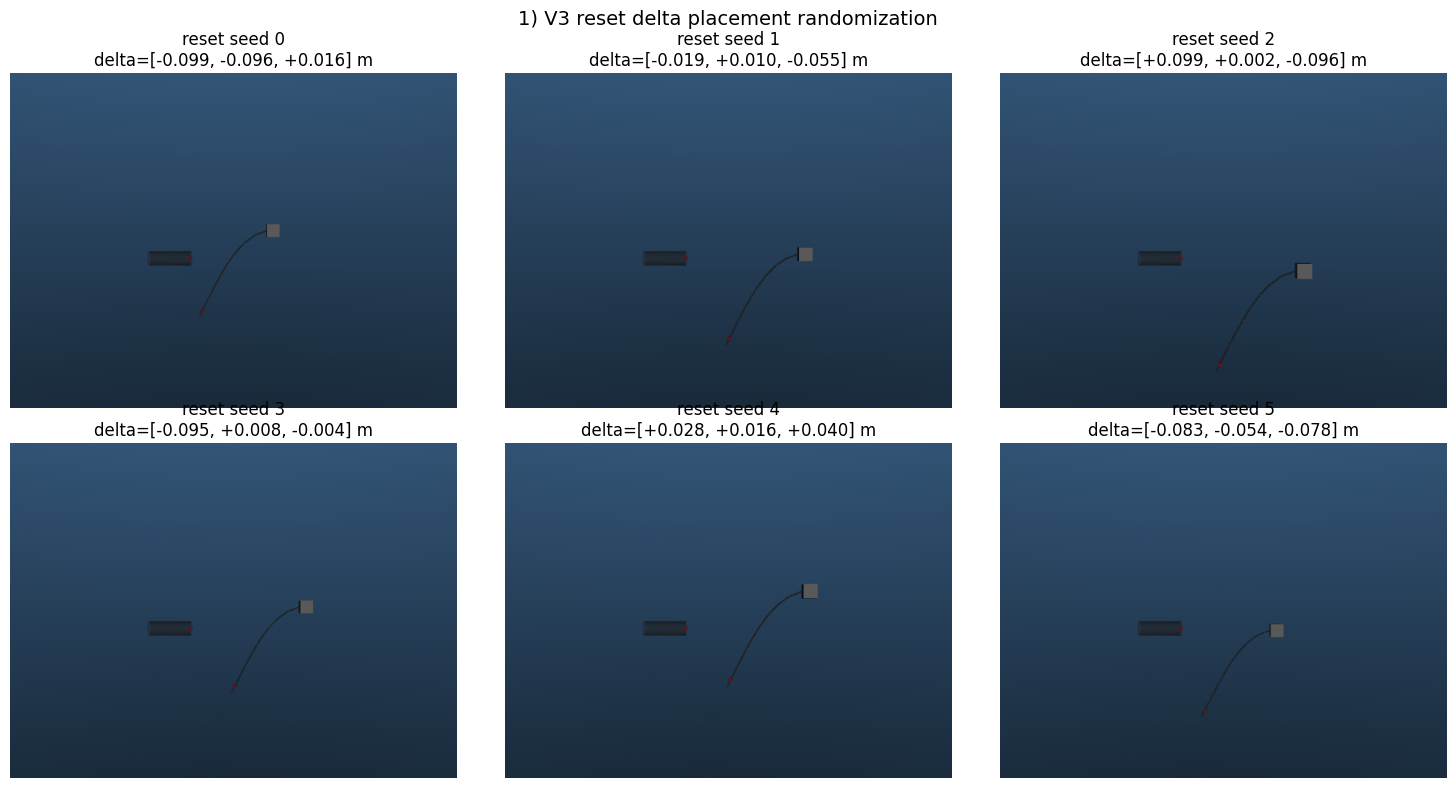

In [4]:
# 1) Delta placement randomization from PipeInsert2.reset().
delta_samples = []
for seed in visualization_seeds:
    _, frame = render_reset_frame(env, seed)
    delta = reset_delta_from_seed(seed)
    delta_samples.append(
        {
            "frame": frame,
            "title": (
                f"reset seed {seed}\n"
                f"delta=[{delta[0]:+.3f}, {delta[1]:+.3f}, {delta[2]:+.3f}] m"
            ),
        }
    )

plot_image_grid(
    delta_samples,
    suptitle="1) V3 reset delta placement randomization",
    out_path=figs_dir / "dr-v3-1-delta-placement.png",
)



Compiling stiffness randomized rollout...
Compilation finished.
Saved figs/dr-v3-2-stiffness-randomization.png


(<Figure size 1500x800 with 6 Axes>,
 array([<Axes: title={'center': 'domain_randomize sample 0\nk=4.376e-04\nspan=[2.304e-04, 2.304e-01]'}>,
        <Axes: title={'center': 'domain_randomize sample 1\nk=1.731e-02\nspan=[2.304e-04, 2.304e-01]'}>,
        <Axes: title={'center': 'domain_randomize sample 2\nk=5.873e-02\nspan=[2.304e-04, 2.304e-01]'}>,
        <Axes: title={'center': 'domain_randomize sample 3\nk=3.708e-02\nspan=[2.304e-04, 2.304e-01]'}>,
        <Axes: title={'center': 'domain_randomize sample 4\nk=1.082e-01\nspan=[2.304e-04, 2.304e-01]'}>,
        <Axes: title={'center': 'domain_randomize sample 5\nk=1.047e-01\nspan=[2.304e-04, 2.304e-01]'}>],
       dtype=object))

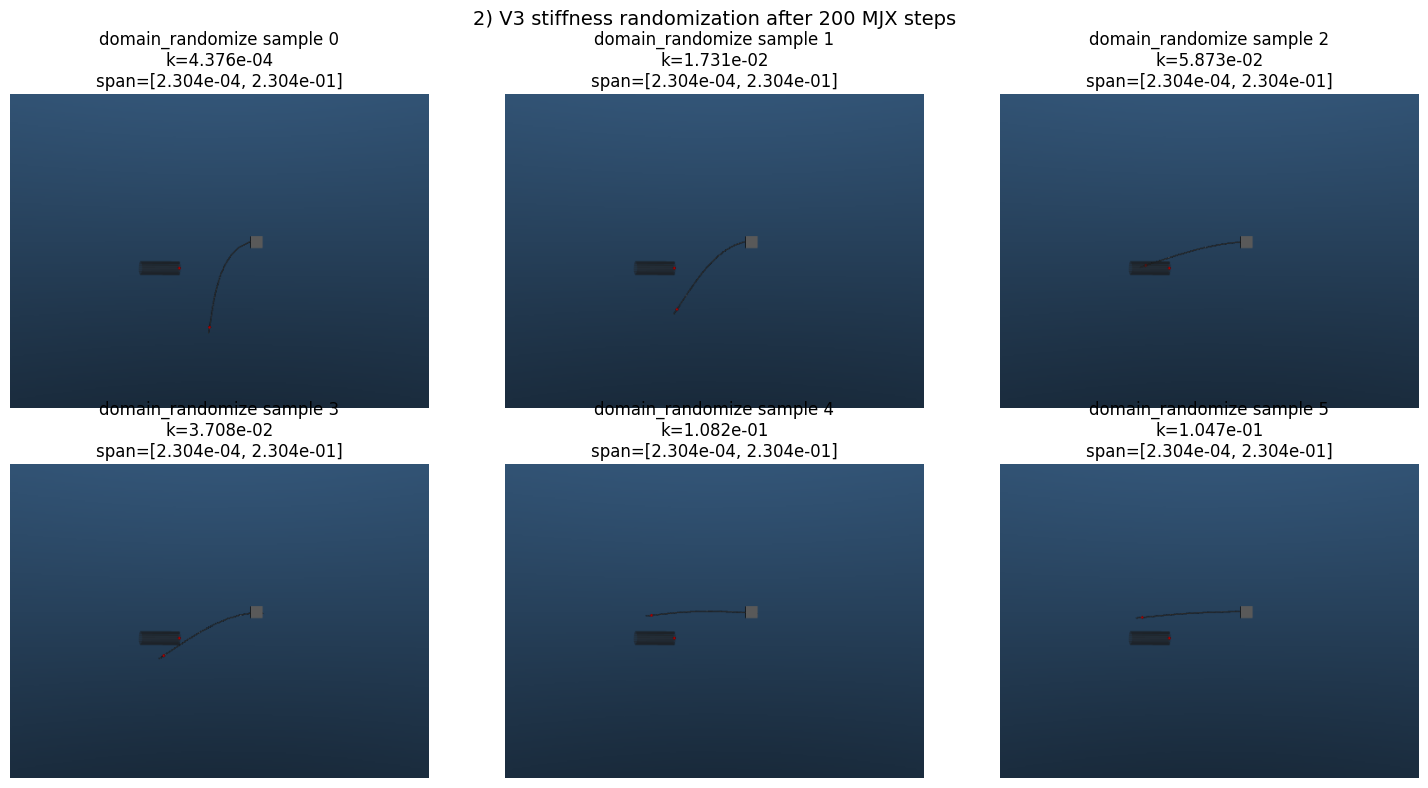

In [5]:
# 2) Stiffness randomization sampled from env.domain_randomize().
num_randomized_models = num_visualization_samples
stiffness_steps = 200
stiffness_seed = 0

spec = cable_randomization_spec(env.mj_model)
domain_k_min, domain_k_max = spec["stiffness_range"]
cable_joint_ids = spec["joint_ids"]
keys = jax.random.split(jax.random.PRNGKey(stiffness_seed), num_randomized_models)

randomized_variants = []
for index, key in enumerate(keys):
    randomized_model, _ = domain_randomize(
        env.mjx_model,
        env.mj_model,
        key,
        cable_youngs_multiplier_range=cable_stiffness_multiplier_range,
        cable_shear_multiplier_range=cable_stiffness_multiplier_range,
        log_uniform=True,
    )
    stiffness = np.asarray(jax.device_get(randomized_model.jnt_stiffness[cable_joint_ids]))
    randomized_variants.append(
        {
            "index": index,
            "key": key,
            "mjx_model": randomized_model,
            "joint_stiffness_mean": float(stiffness.mean()) if stiffness.size else float("nan"),
            "joint_stiffness_min": float(stiffness.min()) if stiffness.size else float("nan"),
            "joint_stiffness_max": float(stiffness.max()) if stiffness.size else float("nan"),
        }
    )

print("Compiling stiffness randomized rollout...")
_compile_state = env.reset(jax.random.PRNGKey(0))
_ = rollout_data(
    randomized_variants[0]["mjx_model"],
    _compile_state.data,
    _compile_state.data.ctrl,
    steps=stiffness_steps,
    n_substeps=env.n_substeps,
)
jax.block_until_ready(_)
print("Compilation finished.")

stiffness_samples = []
for variant in randomized_variants:
    frame = rollout_with_model(
        env,
        variant["mjx_model"],
        seed=0,
        steps=stiffness_steps,
    )
    stiffness_samples.append(
        {
            "frame": frame,
            "title": (
                f"domain_randomize sample {variant['index']}\n"
                f"k={variant['joint_stiffness_mean']:.3e}\n"
                f"span=[{domain_k_min:.3e}, {domain_k_max:.3e}]"
            ),
        }
    )

plot_image_grid(
    stiffness_samples,
    suptitle=f"2) V3 stiffness randomization after {stiffness_steps} MJX steps",
    out_path=figs_dir / "dr-v3-2-stiffness-randomization.png",
)



Compiling cable length randomized rollout...
Compilation finished.
Saved figs/dr-v3-3-length-randomization.png


(<Figure size 1500x800 with 6 Axes>,
 array([<Axes: title={'center': 'length sample 0\nscale=0.925, total=0.370 m\nrange=[0.80, 1.20]'}>,
        <Axes: title={'center': 'length sample 1\nscale=0.887, total=0.355 m\nrange=[0.80, 1.20]'}>,
        <Axes: title={'center': 'length sample 2\nscale=0.873, total=0.349 m\nrange=[0.80, 1.20]'}>,
        <Axes: title={'center': 'length sample 3\nscale=1.197, total=0.479 m\nrange=[0.80, 1.20]'}>,
        <Axes: title={'center': 'length sample 4\nscale=1.080, total=0.432 m\nrange=[0.80, 1.20]'}>,
        <Axes: title={'center': 'length sample 5\nscale=1.103, total=0.441 m\nrange=[0.80, 1.20]'}>],
       dtype=object))

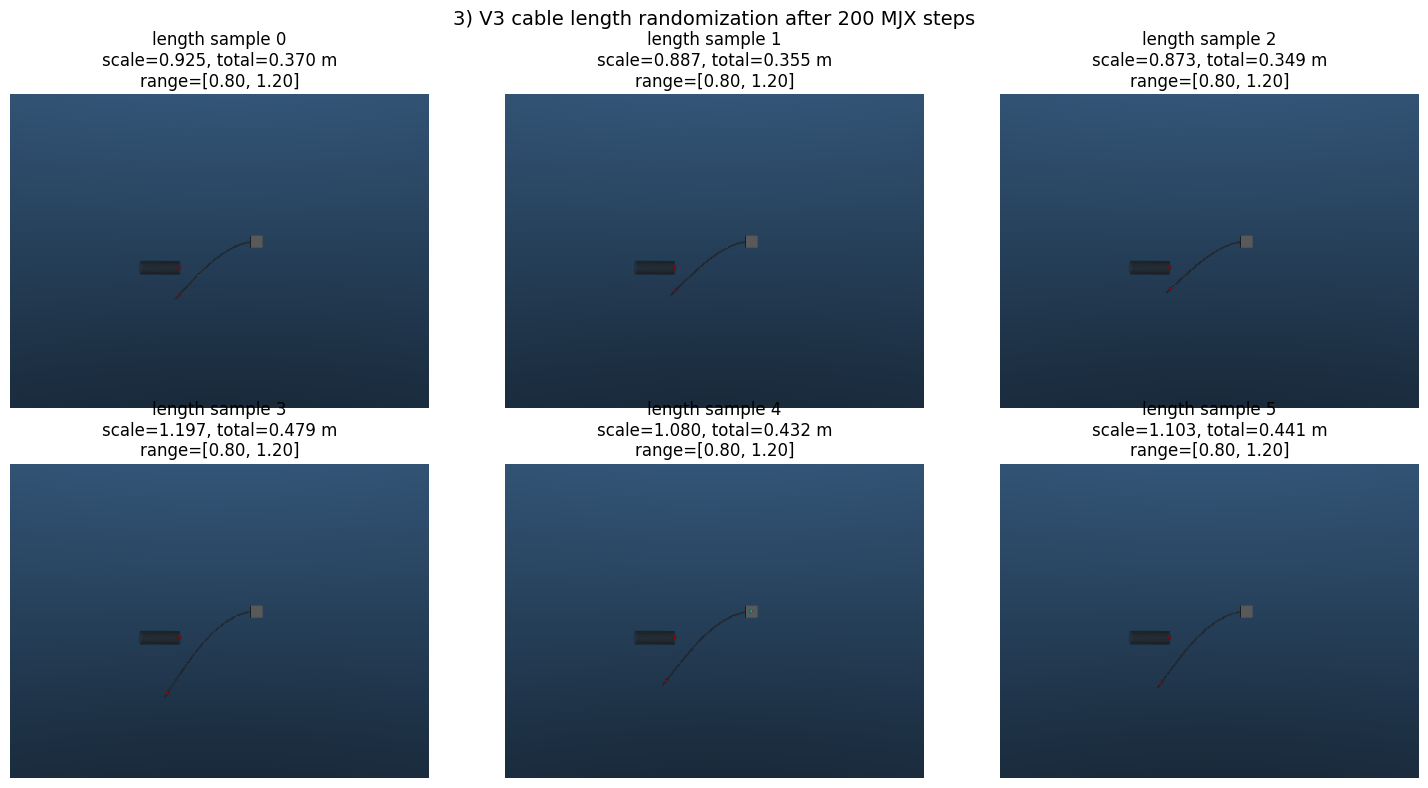

In [6]:
# 3) Cable length randomization sampled like train_drlr_both_dr.randomize_cable_length().
cable_length_scale_range = (0.8, 1.2)
length_steps = 200
length_seed = 123
length_keys = jax.random.split(jax.random.PRNGKey(length_seed), num_visualization_samples)


def cable_length_randomization_spec(mj_model: mj.MjModel) -> dict:
    body_ids = np.array(
        [b for b in range(mj_model.nbody) if mj_model.body(b).name.startswith("cable:B")],
        dtype=np.int32,
    )
    joint_ids = np.array(
        [j for j in range(mj_model.njnt) if mj_model.joint(j).name.startswith("cable:J")],
        dtype=np.int32,
    )
    geom_ids = np.array(
        [g for g in range(mj_model.ngeom) if mj_model.geom(g).name.startswith("cable:G")],
        dtype=np.int32,
    )
    segment_length = 2.0 * float(mj_model.geom_size[int(geom_ids[0]), 1])
    return {
        "body_ids": body_ids,
        "joint_ids": joint_ids,
        "geom_ids": geom_ids,
        "segment_length": segment_length,
        "base_total_length": segment_length * geom_ids.size,
    }


def randomize_cable_length_for_visualization(
    mjx_model: mjx.Model,
    mj_model: mj.MjModel,
    rng: jax.Array,
    scale_range: tuple[float, float],
) -> tuple[mjx.Model, float]:
    spec = cable_length_randomization_spec(mj_model)
    body_ids = spec["body_ids"]
    joint_ids = spec["joint_ids"]
    geom_ids = spec["geom_ids"]
    scale = jax.random.uniform(
        rng,
        shape=(),
        minval=float(scale_range[0]),
        maxval=float(scale_range[1]),
    )

    body_pos = mjx_model.body_pos.at[body_ids, 1].set(mjx_model.body_pos[body_ids, 1] * scale)
    jnt_pos = mjx_model.jnt_pos.at[joint_ids, 1].set(mjx_model.jnt_pos[joint_ids, 1] * scale)
    geom_size = mjx_model.geom_size.at[geom_ids, 1].set(mjx_model.geom_size[geom_ids, 1] * scale)
    geom_rbound = mjx_model.geom_rbound.at[geom_ids].set(
        mjx_model.geom_size[geom_ids, 0] + mjx_model.geom_size[geom_ids, 1] * scale
    )
    jnt_stiffness = mjx_model.jnt_stiffness.at[joint_ids].set(
        mjx_model.jnt_stiffness[joint_ids] / scale
    )
    randomized_model = mjx_model.tree_replace(
        {
            "body_pos": body_pos,
            "jnt_pos": jnt_pos,
            "geom_size": geom_size,
            "geom_rbound": geom_rbound,
            "jnt_stiffness": jnt_stiffness,
        }
    )
    return randomized_model, float(jax.device_get(scale))


length_spec = cable_length_randomization_spec(env.mj_model)
length_samples = []
print("Compiling cable length randomized rollout...")
_compile_model, _compile_scale = randomize_cable_length_for_visualization(
    env.mjx_model,
    env.mj_model,
    length_keys[0],
    cable_length_scale_range,
)
_compile_state = env.reset(jax.random.PRNGKey(0))
_ = rollout_data(
    _compile_model,
    _compile_state.data,
    _compile_state.data.ctrl,
    steps=length_steps,
    n_substeps=env.n_substeps,
)
jax.block_until_ready(_)
print("Compilation finished.")

for index, key in enumerate(length_keys):
    randomized_model, scale = randomize_cable_length_for_visualization(
        env.mjx_model,
        env.mj_model,
        key,
        cable_length_scale_range,
    )
    frame = rollout_with_model(
        env,
        randomized_model,
        seed=0,
        steps=length_steps,
    )
    total_length = length_spec["base_total_length"] * scale
    length_samples.append(
        {
            "frame": frame,
            "title": (
                f"length sample {index}\n"
                f"scale={scale:.3f}, total={total_length:.3f} m\n"
                f"range=[{cable_length_scale_range[0]:.2f}, {cable_length_scale_range[1]:.2f}]"
            ),
        }
    )

plot_image_grid(
    length_samples,
    suptitle=f"3) V3 cable length randomization after {length_steps} MJX steps",
    out_path=figs_dir / "dr-v3-3-length-randomization.png",
)





['cable:Jfirst', 'cable:J2', 'cable:J3', 'cable:J4', 'cable:J5', 'cable:J6', 'cable:J7', 'cable:J8', 'cable:Jlast']


/tmp/ipykernel_2236953/344200829.py:119: DeprecationWarning: nconmax will be deprecated in mujoco-mjx>=3.5. Use naconmax instead.
  data = mjx.make_data(env.mj_model, impl=env.impl, nconmax=4500, njmax=200)


Saved figs/dr-v3-3-precurvature.png


(<Figure size 1500x800 with 6 Axes>,
 array([<Axes: title={'center': 'seed 0\nbend=8.3 deg, phi=268.4 deg'}>,
        <Axes: title={'center': 'seed 1\nbend=113.7 deg, phi=338.8 deg'}>,
        <Axes: title={'center': 'seed 2\nbend=85.3 deg, phi=167.6 deg'}>,
        <Axes: title={'center': 'seed 3\nbend=39.8 deg, phi=267.4 deg'}>,
        <Axes: title={'center': 'seed 4\nbend=15.9 deg, phi=12.4 deg'}>,
        <Axes: title={'center': 'seed 5\nbend=3.4 deg, phi=32.2 deg'}>],
       dtype=object))

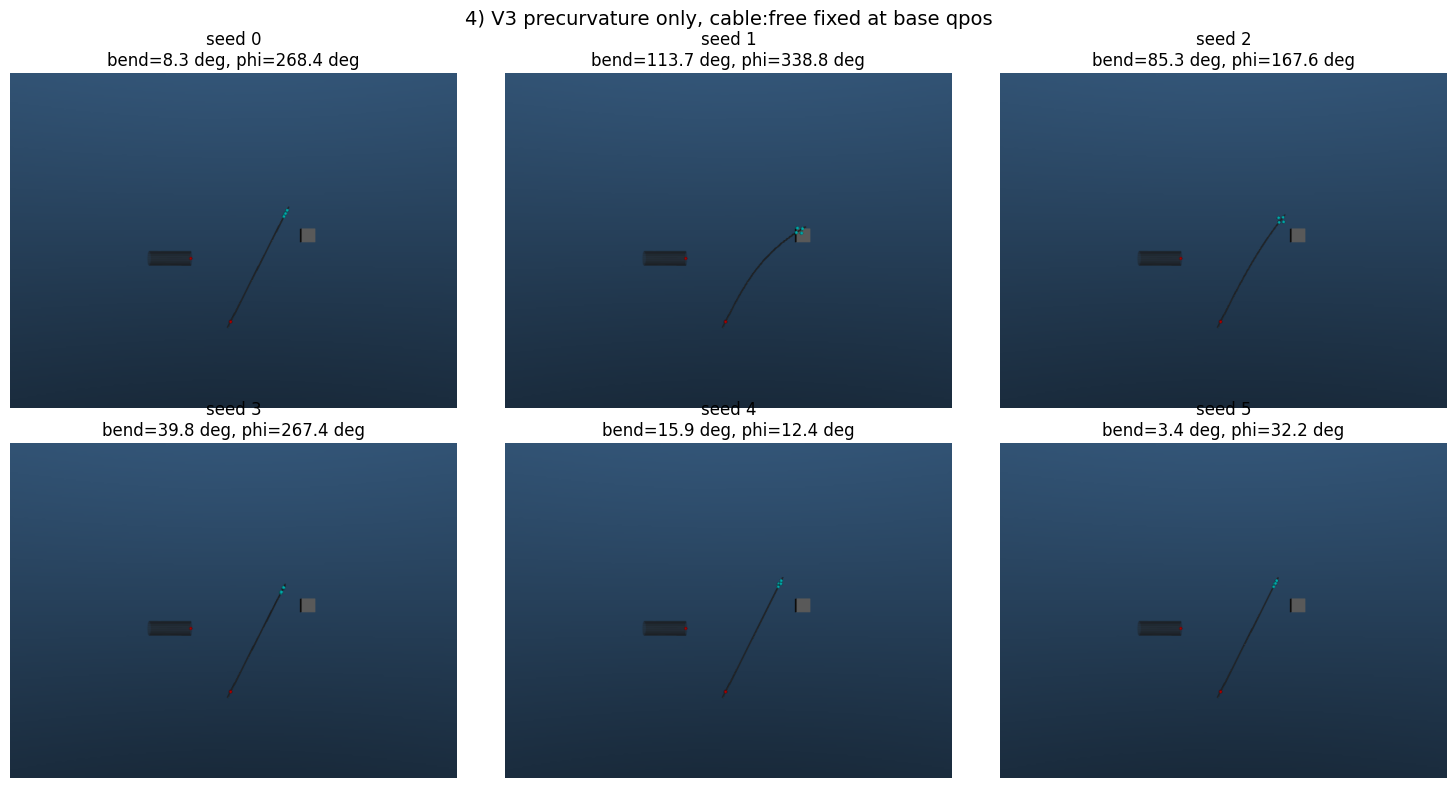

In [7]:
# 4) Precurvature only: build data directly from the base qpos without reset placement delta.
precurvature_bend_range = (0.0, math.radians(120.0))  # total bend over the cable, radians
precurvature_phi_range = (0.0, 2.0 * math.pi)

curvature_cfg = default_config()
curvature_cfg.impl = "jax"
curvature_cfg.episode_length = 300
curvature_cfg.randomize_cable_curvature = True
curvature_cfg.cable_curvature_bend_range = precurvature_bend_range
curvature_cfg.cable_curvature_phi_range = precurvature_phi_range
curvature_cfg.cable_curvature_num_cables = 1
curvature_env = PipeInsert2(config=curvature_cfg)

precurvature_samples = []
for seed in visualization_seeds:
    data = data_with_precurvature_only(
        curvature_env,
        seed,
        precurvature_bend_range,
        precurvature_phi_range,
    )
    frame = render_mjx_data(curvature_env.mj_model, data)
    total_bend, azimuth_phi = precurvature_params_from_seed(
        seed,
        precurvature_bend_range,
        precurvature_phi_range,
    )
    precurvature_samples.append(
        {
            "frame": frame,
            "title": (
                f"seed {seed}\n"
                f"bend={math.degrees(total_bend):.1f} deg, "
                f"phi={math.degrees(azimuth_phi):.1f} deg"
            ),
        }
    )

plot_image_grid(
    precurvature_samples,
    suptitle="4) V3 precurvature only, cable:free fixed at base qpos",
    out_path=figs_dir / "dr-v3-3-precurvature.png",
)



['cable:Jfirst', 'cable:J2', 'cable:J3', 'cable:J4', 'cable:J5', 'cable:J6', 'cable:J7', 'cable:J8', 'cable:Jlast']
Compiling combined randomized rollout...


Compilation finished.
Saved figs/dr-v3-5-all-combined.png


(<Figure size 1500x800 with 6 Axes>,
 array([<Axes: title={'center': 'sample 0 | |delta|=0.138 m\nbend=8.3 deg, phi=268.4 deg\nk=3.236e-03 span=[2.304e-04, 2.304e-01]'}>,
        <Axes: title={'center': 'sample 1 | |delta|=0.060 m\nbend=113.7 deg, phi=338.8 deg\nk=1.502e-02 span=[2.304e-04, 2.304e-01]'}>,
        <Axes: title={'center': 'sample 2 | |delta|=0.138 m\nbend=85.3 deg, phi=167.6 deg\nk=1.091e-02 span=[2.304e-04, 2.304e-01]'}>,
        <Axes: title={'center': 'sample 3 | |delta|=0.095 m\nbend=39.8 deg, phi=267.4 deg\nk=2.386e-02 span=[2.304e-04, 2.304e-01]'}>,
        <Axes: title={'center': 'sample 4 | |delta|=0.051 m\nbend=15.9 deg, phi=12.4 deg\nk=1.000e-01 span=[2.304e-04, 2.304e-01]'}>,
        <Axes: title={'center': 'sample 5 | |delta|=0.126 m\nbend=3.4 deg, phi=32.2 deg\nk=1.356e-02 span=[2.304e-04, 2.304e-01]'}>],
       dtype=object))

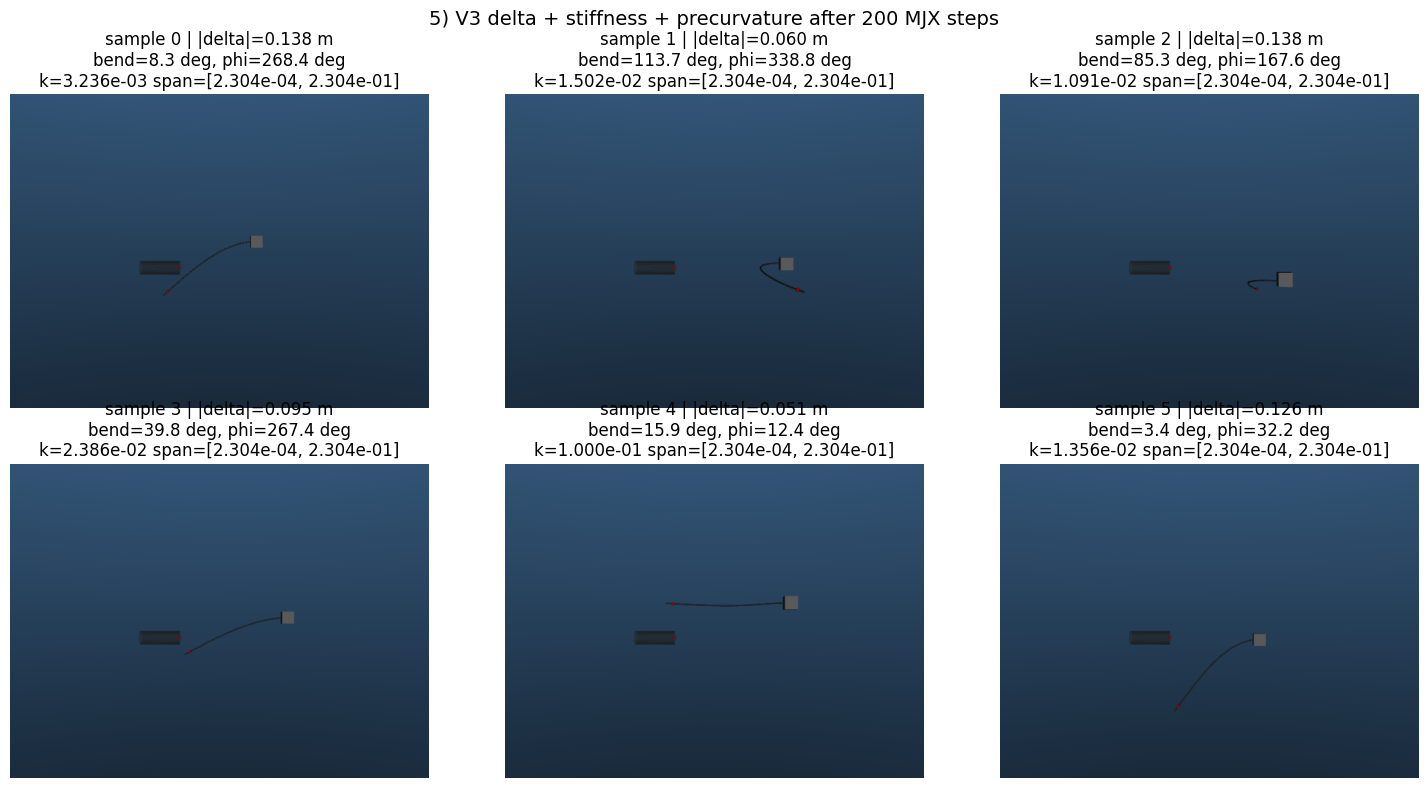

In [8]:
# 5) Delta placement + stiffness randomization + reset precurvature combined.
combined_steps = 200
combined_keys = jax.random.split(jax.random.PRNGKey(42), num_visualization_samples)

combined_cfg = default_config()
combined_cfg.impl = "jax"
combined_cfg.episode_length = 300
combined_cfg.randomize_cable_curvature = True
combined_cfg.cable_curvature_bend_range = precurvature_bend_range
combined_cfg.cable_curvature_phi_range = precurvature_phi_range
combined_cfg.cable_curvature_num_cables = 1
combined_env = PipeInsert2(config=combined_cfg)
combined_spec = cable_randomization_spec(combined_env.mj_model)
combined_joint_ids = combined_spec["joint_ids"]
combined_k_min, combined_k_max = combined_spec["stiffness_range"]

combined_samples = []
print("Compiling combined randomized rollout...")
_compile_state = combined_env.reset(jax.random.PRNGKey(0))
_compile_model, _ = domain_randomize(
    combined_env.mjx_model,
    combined_env.mj_model,
    combined_keys[0],
    cable_youngs_multiplier_range=cable_stiffness_multiplier_range,
    cable_shear_multiplier_range=cable_stiffness_multiplier_range,
    log_uniform=True,
)
_ = rollout_data(
    _compile_model,
    _compile_state.data,
    _compile_state.data.ctrl,
    steps=combined_steps,
    n_substeps=combined_env.n_substeps,
)
jax.block_until_ready(_)
print("Compilation finished.")

for index, (seed, key) in enumerate(zip(visualization_seeds, combined_keys)):
    randomized_model, _ = domain_randomize(
        combined_env.mjx_model,
        combined_env.mj_model,
        key,
        cable_youngs_multiplier_range=cable_stiffness_multiplier_range,
        cable_shear_multiplier_range=cable_stiffness_multiplier_range,
        log_uniform=True,
    )
    stiffness = np.asarray(jax.device_get(randomized_model.jnt_stiffness[combined_joint_ids]))
    state = combined_env.reset(jax.random.PRNGKey(seed))
    data = rollout_data(
        randomized_model,
        state.data,
        state.data.ctrl,
        steps=combined_steps,
        n_substeps=combined_env.n_substeps,
    )
    frame = render_mjx_data(combined_env.mj_model, data)
    delta = reset_delta_from_seed(seed)
    total_bend, azimuth_phi = precurvature_params_from_seed(
        seed,
        precurvature_bend_range,
        precurvature_phi_range,
    )
    combined_samples.append(
        {
            "frame": frame,
            "title": (
                f"sample {index} | |delta|={np.linalg.norm(delta):.3f} m\n"
                f"bend={math.degrees(total_bend):.1f} deg, "
                f"phi={math.degrees(azimuth_phi):.1f} deg\n"
                f"k={float(stiffness.mean()):.3e} "
                f"span=[{combined_k_min:.3e}, {combined_k_max:.3e}]"
            ),
        }
    )

plot_image_grid(
    combined_samples,
    suptitle=f"5) V3 delta + stiffness + precurvature after {combined_steps} MJX steps",
    out_path=figs_dir / "dr-v3-5-all-combined.png",
)

